# Bab 3 — Introduction to Neural Prediction: Forward Propagation

Notebook ini merangkum **Bab 3** buku *Grokking Deep Learning* (Andrew W. Trask, 2019).

Siklus belajar neural network adalah **predict → compare → learn**. Bab ini fokus pada langkah pertama: **predict**, yang secara teknis disebut **forward propagation** — mengalirkan input melalui bobot (*weights*) hingga menghasilkan prediksi. Kita membangun network dari yang paling sederhana (1 bobot) hingga network bertumpuk dengan hidden layer, pertama dengan Python murni lalu dengan NumPy.

Isi notebook:
1. Step 1: Predict — data, bobot, prediksi
2. Neural network paling sederhana (1 input, 1 output)
3. Apa sebenarnya neural network? Apa yang ia lakukan?
4. Multiple inputs — *weighted sum* / *dot product*
5. Dot product sebagai ukuran kemiripan
6. Multiple outputs — *elementwise multiplication*
7. Multiple inputs & outputs — *vector-matrix multiplication*
8. Predicting on predictions — hidden layer
9. Primer NumPy

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Step 1: Predict

Bab ini hanya membahas langkah **predict**. Gambaran besarnya:

```
[data] --> [machine (bobot)] --> [prediction]
```

**Berapa banyak data yang dimasukkan sekaligus?** Network hanya menerima satu *datapoint* per prediksi — misalnya statistik **satu pertandingan** — lalu memprediksi hasil pertandingan itu. Kita bisa memilih seberapa banyak informasi yang menjadi satu datapoint (satu angka, atau beberapa angka sekaligus).

Dataset mainan yang dipakai sepanjang bab: statistik 4 pertandingan sebuah tim bisbol.

| Variabel | Arti |
|---|---|
| `toes` | rata-rata jumlah jari kaki pemain |
| `wlrec` | rasio menang–kalah (*win/loss record*) saat ini |
| `nfans` | jumlah penggemar (dalam jutaan) |

In [2]:
toes  = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

print(f'{"game":>4} {"toes":>5} {"wlrec":>6} {"nfans":>6}')
for g in range(4):
    print(f'{g:>4} {toes[g]:>5} {wlrec[g]:>6} {nfans[g]:>6}')

game  toes  wlrec  nfans
   0   8.5   0.65    1.2
   1   9.5    0.8    1.3
   2   9.9    0.8    0.5
   3   9.0    0.9    1.0


## 2. Neural Network Paling Sederhana

**Neural network** pada dasarnya adalah **satu atau lebih bobot yang dikalikan dengan data input** untuk menghasilkan prediksi.

$$\hat{y} = x \cdot w$$

In [3]:
weight = 0.1

def neural_network(input, weight):
    prediction = input * weight
    return prediction

number_of_toes = [8.5, 9.5, 10, 9]
input = number_of_toes[0]
pred = neural_network(input, weight)
print('Prediksi:', pred)

Prediksi: 0.8500000000000001


## 3. Apa Sebenarnya Neural Network? Apa yang Ia Lakukan?

Kode di atas adalah neural network pertama kita. Langkah-langkahnya:

| Langkah | Yang terjadi | Nilai |
|---|---|---|
| 1. Kosong | Network dengan satu bobot | `weight = 0.1` |
| 2. Masukkan satu input | Rata-rata jari kaki | `input = 8.5` |
| 3. Kalikan input dengan bobot | `8.5 × 0.1` | `0.85` |
| 4. Hasilkan prediksi | Peluang menang 85% | `0.85` |

Istilah penting:
- **Input data** — angka yang direkam dari dunia nyata dan *mudah diketahui* (suhu hari ini, statistik pemain, ...).
- **Prediction** — apa yang network katakan berdasarkan input (misal peluang menang). Prediksi tidak selalu benar; network belajar dari kesalahannya (Bab 4).
- **Weight** — "kenop" yang menentukan seberapa besar input memengaruhi prediksi.

Tiga cara memandang bobot:
1. **Volume knob** — bobot memperbesar/memperkecil input. `weight = 2` menggandakan input, `0.5` menjadikannya setengah, bobot negatif membalik tandanya.
2. **Sensitivitas** — seberapa sensitif prediksi terhadap perubahan input.
3. **Memori** — bobot adalah satu-satunya hal yang "diingat" network. Network **tidak mengingat prediksi sebelumnya**; setiap prediksi hanya bergantung pada input saat itu dan bobotnya.

game 0: input= 8.5  x  weight=0.1  =  prediksi 0.85
game 1: input= 9.5  x  weight=0.1  =  prediksi 0.95
game 2: input=  10  x  weight=0.1  =  prediksi 1.00
game 3: input=   9  x  weight=0.1  =  prediksi 0.90


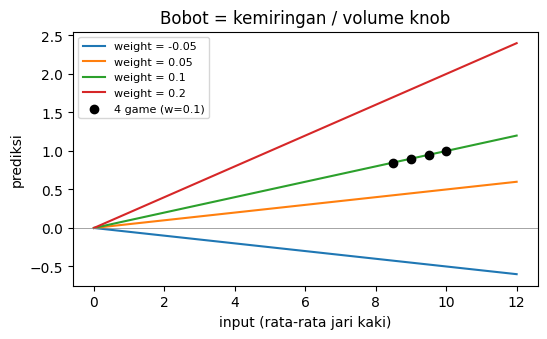

In [4]:
# Prediksi untuk keempat pertandingan, langkah demi langkah
for g, t in enumerate(number_of_toes):
    pred = neural_network(t, weight)
    print(f'game {g}: input={t:4}  x  weight={weight}  =  prediksi {pred:.2f}')

# Pengaruh bobot sebagai "volume knob"
x = np.linspace(0, 12, 50)
plt.figure(figsize=(6, 3.3))
for w in [-0.05, 0.05, 0.1, 0.2]:
    plt.plot(x, x * w, label=f'weight = {w}')
plt.scatter(number_of_toes, [t * 0.1 for t in number_of_toes], color='k', zorder=3, label='4 game (w=0.1)')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('input (rata-rata jari kaki)'); plt.ylabel('prediksi'); plt.legend(fontsize=8)
plt.title('Bobot = kemiringan / volume knob')
plt.show()

## 4. Multiple Inputs — Weighted Sum

Satu input jarang cukup. Network bisa memakai **beberapa input sekaligus**: setiap input dikalikan bobotnya sendiri lalu **dijumlahkan**.

$$\hat{y} = \sum_i x_i w_i = x_1 w_1 + x_2 w_2 + x_3 w_3$$

Operasi ini disebut **weighted sum** atau **dot product** dari vektor input dan vektor bobot. Python list yang berisi deretan angka disebut **vektor**.

In [5]:
def w_sum(a, b):
    assert len(a) == len(b)
    output = 0
    for i in range(len(a)):
        output += a[i] * b[i]
    return output

weights = [0.1, 0.2, 0]

def neural_network(input, weights):
    pred = w_sum(input, weights)
    return pred

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)
print('Prediksi:', pred)

Prediksi: 0.9800000000000001


### Apa yang dilakukan network ini?
Setiap input dikalikan bobotnya (*elementwise*), lalu semuanya dijumlahkan. Mari lihat **kontribusi** masing-masing input:

toes  :   8.5 x  0.1 = 0.850
wlrec :  0.65 x  0.2 = 0.130
nfans :   1.2 x    0 = 0.000
total : 0.980


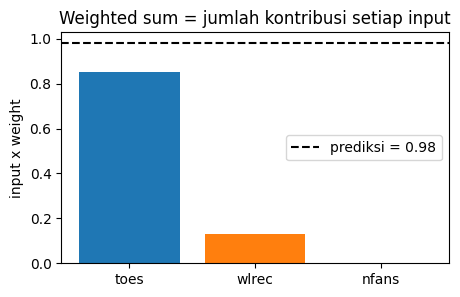

In [6]:
names = ['toes', 'wlrec', 'nfans']
contrib = [i * w for i, w in zip(input, weights)]
for n, i, w, c in zip(names, input, weights, contrib):
    print(f'{n:6s}: {i:5} x {w:4} = {c:.3f}')
print(f'{"total":6s}: {sum(contrib):.3f}')

plt.figure(figsize=(5, 3))
plt.bar(names, contrib, color=['C0', 'C1', 'C2'])
plt.axhline(sum(contrib), color='k', ls='--', label=f'prediksi = {sum(contrib):.2f}')
plt.ylabel('input x weight'); plt.legend()
plt.title('Weighted sum = jumlah kontribusi setiap input')
plt.show()

Bobot `nfans = 0` berarti network **mengabaikan** jumlah fans. Bobot `wlrec = 0.2` lebih besar dari `toes = 0.1`, tetapi karena nilai `toes` (8.5) jauh lebih besar dari `wlrec` (0.65), kontribusi `toes` tetap mendominasi. Pelajaran: **besar kontribusi = input × bobot**, bukan bobot saja.

In [7]:
# Versi lengkap (multiple inputs: complete runnable code) untuk keempat pertandingan
for g in range(4):
    inp = [toes[g], wlrec[g], nfans[g]]
    print(f'game {g}: input={inp} -> prediksi {neural_network(inp, weights):.3f}')

game 0: input=[8.5, 0.65, 1.2] -> prediksi 0.980
game 1: input=[9.5, 0.8, 1.3] -> prediksi 1.110
game 2: input=[9.9, 0.8, 0.5] -> prediksi 1.150
game 3: input=[9.0, 0.9, 1.0] -> prediksi 1.080


## 5. Dot Product sebagai Ukuran Kemiripan

Dot product mengukur **seberapa mirip** dua vektor. Contoh dari buku:

In [8]:
a = [0, 1, 0, 1]
b = [1, 0, 1, 0]
c = [0, 1, 1, 0]
d = [0.5, 0, 0.5, 0]
e = [0, 1, -1, 0]

print('w_sum(a, b) =', w_sum(a, b), '<- tidak ada posisi aktif bersama')
print('w_sum(b, c) =', w_sum(b, c))
print('w_sum(b, d) =', w_sum(b, d))
print('w_sum(c, c) =', w_sum(c, c), '<- vektor identik -> paling besar')
print('w_sum(d, d) =', w_sum(d, d))
print('w_sum(c, e) =', w_sum(c, e), '<- bobot negatif membatalkan')

w_sum(a, b) = 0 <- tidak ada posisi aktif bersama
w_sum(b, c) = 1
w_sum(b, d) = 1.0
w_sum(c, c) = 2 <- vektor identik -> paling besar
w_sum(d, d) = 0.5
w_sum(c, e) = 0 <- bobot negatif membatalkan


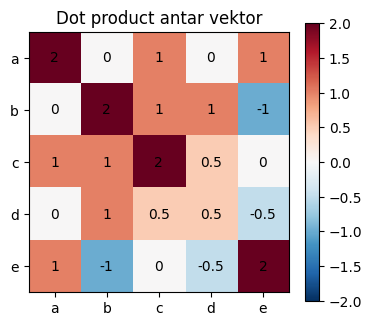

In [9]:
vecs = {'a': a, 'b': b, 'c': c, 'd': d, 'e': e}
names_v = list(vecs)
mat = np.array([[w_sum(vecs[i], vecs[j]) for j in names_v] for i in names_v])

fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(mat, cmap='RdBu_r', vmin=-2, vmax=2)
ax.set_xticks(range(5), names_v); ax.set_yticks(range(5), names_v)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{mat[i, j]:g}', ha='center', va='center')
plt.colorbar(im); plt.title('Dot product antar vektor')
plt.show()

Interpretasi logika ala buku:
- Dot product berperilaku seperti **logical AND** yang lunak: nilainya besar hanya jika kedua vektor bernilai tinggi **di posisi yang sama**.
- Bobot **negatif** berperilaku seperti **NOT**: input di posisi itu justru menurunkan prediksi.

Jadi, network multiple inputs pada dasarnya memberi skor tinggi jika input **mirip** dengan pola bobotnya.

### Versi NumPy
`np.array` dan `.dot()` membuat kode jauh lebih ringkas — dan hasilnya sama:

In [10]:
weights = np.array([0.1, 0.2, 0])

def neural_network(input, weights):
    pred = input.dot(weights)
    return pred

toes  = np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

input = np.array([toes[0], wlrec[0], nfans[0]])
pred = neural_network(input, weights)
print('Prediksi:', pred)

# NumPy juga mendukung operasi elementwise langsung
print('Elementwise input * weights:', input * weights, '-> jumlah:', (input * weights).sum())

Prediksi: 0.9800000000000001
Elementwise input * weights: [0.85 0.13 0.  ] -> jumlah: 0.9800000000000001


## 6. Multiple Outputs — Elementwise Multiplication

Network juga bisa membuat **beberapa prediksi dari satu input**. Contoh: dari `wlrec` saja, prediksi tiga hal sekaligus — apakah pemain **cedera** (*hurt*), apakah tim **menang** (*win*), dan apakah pemain **sedih** (*sad*).

Setiap output punya bobotnya sendiri dan **dihitung independen** — ini pada dasarnya tiga network 1-bobot yang berbagi input yang sama:

$$\hat{y}_j = x \cdot w_j$$

In [11]:
def ele_mul(number, vector):
    output = [0, 0, 0]
    assert len(output) == len(vector)
    for i in range(len(vector)):
        output[i] = number * vector[i]
    return output

weights = [0.3, 0.2, 0.9]   # hurt?, win?, sad?

def neural_network(input, weights):
    pred = ele_mul(input, weights)
    return pred

wlrec = [0.65, 0.8, 0.8, 0.9]
input = wlrec[0]
pred = neural_network(input, weights)
print('hurt? win? sad? ->', np.round(pred, 3))

hurt? win? sad? -> [0.195 0.13  0.585]


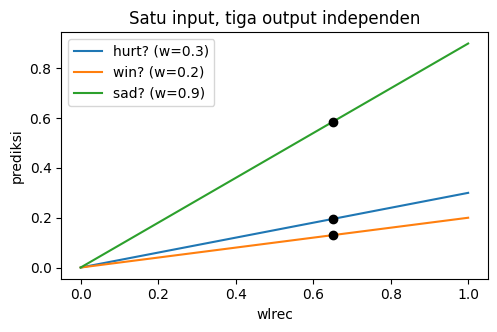

In [12]:
# Ketiga output naik-turun bersama input yang sama, dengan kemiringan berbeda
x = np.linspace(0, 1, 50)
plt.figure(figsize=(5.5, 3.2))
for w, name in zip(weights, ['hurt?', 'win?', 'sad?']):
    plt.plot(x, x * w, label=f'{name} (w={w})')
plt.scatter([wlrec[0]] * 3, pred, color='k', zorder=3)
plt.xlabel('wlrec'); plt.ylabel('prediksi'); plt.legend()
plt.title('Satu input, tiga output independen')
plt.show()

## 7. Multiple Inputs & Multiple Outputs — Vector-Matrix Multiplication

Gabungan dua kasus di atas: **3 input → 3 output**. Bobot sekarang berupa **matriks** 3×3; setiap **baris** adalah bobot untuk satu output. Setiap output adalah **weighted sum** dari semua input:

$$\hat{\mathbf{y}} = W \mathbf{x} \quad\Longleftrightarrow\quad \hat{y}_j = \sum_i W_{ji}\, x_i$$

```
            #toes  %win  #fans
weights = [ [0.1,  0.1, -0.3],   # hurt?
            [0.1,  0.2,  0.0],   # win?
            [0.0,  1.3,  0.1] ]  # sad?
```

Cara memandangnya: **tiga weighted sum independen** dari input yang sama — atau tiga "detektor" yang masing-masing menghitung kemiripan input dengan barisnya.

In [13]:
def vect_mat_mul(vect, matrix):
    assert len(vect) == len(matrix)
    output = [0, 0, 0]
    for i in range(len(vect)):
        output[i] = w_sum(vect, matrix[i])
    return output

weights = [[0.1, 0.1, -0.3],   # hurt?
           [0.1, 0.2,  0.0],   # win?
           [0.0, 1.3,  0.1]]   # sad?

def neural_network(input, weights):
    pred = vect_mat_mul(input, weights)
    return pred

toes  = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

input = [toes[0], wlrec[0], nfans[0]]
pred = neural_network(input, weights)
print('hurt? win? sad? ->', np.round(pred, 3))

hurt? win? sad? -> [0.555 0.98  0.965]


In [14]:
# Bagaimana cara kerjanya: setiap output = weighted sum baris bobotnya dengan input
for row, name in zip(weights, ['hurt?', 'win?', 'sad?']):
    terms = ' + '.join(f'{i}*{w}' for i, w in zip(input, row))
    print(f'{name:5s} = {terms} = {w_sum(input, row):.3f}')

# Sama persis dengan perkalian matriks NumPy
print('\nNumPy W.dot(x):', np.array(weights).dot(np.array(input)).round(3))

hurt? = 8.5*0.1 + 0.65*0.1 + 1.2*-0.3 = 0.555
win?  = 8.5*0.1 + 0.65*0.2 + 1.2*0.0 = 0.980
sad?  = 8.5*0.0 + 0.65*1.3 + 1.2*0.1 = 0.965

NumPy W.dot(x): [0.555 0.98  0.965]


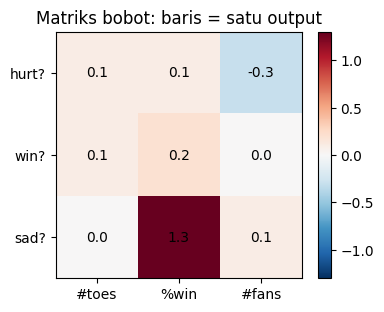

In [15]:
W = np.array(weights)
fig, ax = plt.subplots(figsize=(4.2, 3.2))
im = ax.imshow(W, cmap='RdBu_r', vmin=-1.3, vmax=1.3)
ax.set_xticks(range(3), ['#toes', '%win', '#fans'])
ax.set_yticks(range(3), ['hurt?', 'win?', 'sad?'])
for i in range(3):
    for j in range(3):
        ax.text(j, i, W[i, j], ha='center', va='center')
plt.colorbar(im); plt.title('Matriks bobot: baris = satu output')
plt.show()

## 8. Predicting on Predictions — Hidden Layer

Output satu network bisa menjadi **input network lain**. Hasilnya adalah network bertumpuk (*stacked*) dengan **hidden layer** (`hid`) di tengah:

$$\mathbf{h} = W_{ih}\,\mathbf{x}, \qquad \hat{\mathbf{y}} = W_{hp}\,\mathbf{h}$$

Inilah cikal bakal **deep** learning: banyak layer yang ditumpuk. (Mengapa menumpuk layer berguna — dan mengapa butuh *nonlinearity* — dijelaskan di Bab 6.)

In [16]:
            # toes %win #fans
ih_wgt = [[0.1, 0.2, -0.1],   # hid[0]
          [-0.1, 0.1, 0.9],   # hid[1]
          [0.1, 0.4, 0.1]]    # hid[2]

            # hid[0] hid[1] hid[2]
hp_wgt = [[0.3, 1.1, -0.3],   # hurt?
          [0.1, 0.2, 0.0],    # win?
          [0.0, 1.3, 0.1]]    # sad?

weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):
    hid = vect_mat_mul(input, weights[0])
    pred = vect_mat_mul(hid, weights[1])
    return pred

input = [toes[0], wlrec[0], nfans[0]]
hid = vect_mat_mul(input, ih_wgt)
pred = neural_network(input, weights)
print('input  :', input)
print('hidden :', np.round(hid, 3))
print('pred   :', np.round(pred, 3), '(hurt?, win?, sad?)')

input  : [8.5, 0.65, 1.2]
hidden : [0.86  0.295 1.23 ]
pred   : [0.214 0.145 0.506] (hurt?, win?, sad?)


### Versi NumPy
Dengan NumPy, satu layer = satu `dot`. Matriks bobot di-transpose (`.T`) karena pada definisi di atas setiap **baris** menyimpan bobot satu neuron output, sedangkan `input.dot(W)` mengharapkan setiap **kolom** yang menyimpannya.

Bonusnya: dengan menumpuk beberapa input sebagai baris matriks, kita bisa memprediksi **semua pertandingan sekaligus** dalam satu operasi.

In [17]:
ih_wgt = np.array(ih_wgt).T
hp_wgt = np.array(hp_wgt).T
weights = [ih_wgt, hp_wgt]

def neural_network(input, weights):
    hid = input.dot(weights[0])
    pred = hid.dot(weights[1])
    return pred

toes  = np.array([8.5, 9.5, 9.9, 9.0])
wlrec = np.array([0.65, 0.8, 0.8, 0.9])
nfans = np.array([1.2, 1.3, 0.5, 1.0])

input = np.array([toes[0], wlrec[0], nfans[0]])
print('Game 0 -> hurt? win? sad? =', neural_network(input, weights).round(3))

X = np.stack([toes, wlrec, nfans], axis=1)      # shape (4 game, 3 input)
P = neural_network(X, weights)                  # shape (4 game, 3 output)
print('\nPrediksi semua pertandingan (baris = game):\n', P.round(3))

Game 0 -> hurt? win? sad? = [0.213 0.145 0.506]

Prediksi semua pertandingan (baris = game):
 [[ 0.213  0.145  0.506]
 [ 0.204  0.158  0.53 ]
 [-0.584  0.018 -0.462]
 [-0.015  0.116  0.253]]


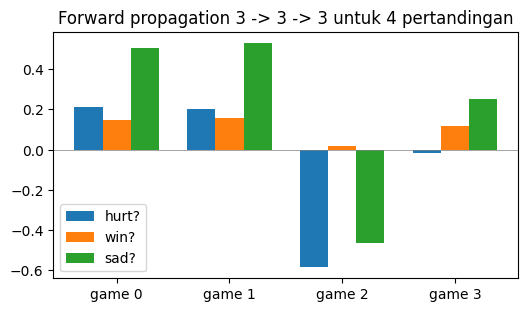

In [18]:
fig, ax = plt.subplots(figsize=(6, 3.2))
xpos = np.arange(4)
for k, name in enumerate(['hurt?', 'win?', 'sad?']):
    ax.bar(xpos + (k - 1) * 0.25, P[:, k], width=0.25, label=name)
ax.set_xticks(xpos, [f'game {g}' for g in range(4)])
ax.axhline(0, color='gray', lw=0.5); ax.legend()
ax.set_title('Forward propagation 3 -> 3 -> 3 untuk 4 pertandingan')
plt.show()

## 9. Primer NumPy

Operasi NumPy yang terus dipakai di buku ini:

In [19]:
a = np.array([0, 1, 2, 3])      # vektor
b = np.array([4, 5, 6, 7])
c = np.array([[0, 1, 2, 3],     # matriks
              [4, 5, 6, 7]])
d = np.zeros((2, 4))            # matriks nol 2x4
e = np.random.rand(2, 5)        # matriks acak 2x5

print('a * 0.1  =', a * 0.1)            # kali skalar
print('a * b    =', a * b)              # elementwise
print('a + b    =', a + b)
print('c * a    =\n', c * a)            # broadcasting: tiap baris c dikali a
print('a.dot(b) =', a.dot(b))           # dot product
print('shape c  =', c.shape, '| shape e =', e.shape)

a * 0.1  = [0.  0.1 0.2 0.3]
a * b    = [ 0  5 12 21]
a + b    = [ 4  6  8 10]
c * a    =
 [[ 0  1  4  9]
 [ 0  5 12 21]]
a.dot(b) = 38
shape c  = (2, 4) | shape e = (2, 5)


In [20]:
# Reshape, transpose, dan agregasi per sumbu
m = np.arange(6)
print('arange      :', m)
print('reshape(2,3):\n', m.reshape(2, 3))
print('transpose   :\n', m.reshape(2, 3).T)
print('sum axis=0  :', m.reshape(2, 3).sum(axis=0), '(per kolom)')
print('sum axis=1  :', m.reshape(2, 3).sum(axis=1), '(per baris)')
print('argmax      :', np.array([0.2, 0.9, 0.1]).argmax(), '(indeks nilai terbesar)')

arange      : [0 1 2 3 4 5]
reshape(2,3):
 [[0 1 2]
 [3 4 5]]
transpose   :
 [[0 3]
 [1 4]
 [2 5]]
sum axis=0  : [3 5 7] (per kolom)
sum axis=1  : [ 3 12] (per baris)
argmax      : 1 (indeks nilai terbesar)


In [21]:
# Aturan shape pada dot product: (m, n) . (n, k) -> (m, k). Kolom kiri harus = baris kanan.
print('(1,4).(4,3) ->', np.zeros((1, 4)).dot(np.zeros((4, 3))).shape)
print('(2,1).(1,3) ->', np.zeros((2, 1)).dot(np.zeros((1, 3))).shape)
print('(4,)·(4,)   ->', np.zeros(4).dot(np.zeros(4)).shape, '(skalar)')

try:
    np.zeros((5, 4)).dot(np.zeros((5, 6)))
except ValueError as err:
    print('(5,4).(5,6) -> ERROR:', err)

(1,4).(4,3) -> (1, 3)
(2,1).(1,3) -> (2, 3)
(4,)·(4,)   -> () (skalar)
(5,4).(5,6) -> ERROR: shapes (5,4) and (5,6) not aligned: 4 (dim 1) != 5 (dim 0)


## Latihan

1. Buat network multiple inputs untuk **4 input** (tambahkan input `home` = 1 jika bermain di kandang) dengan bobot `[0.1, 0.2, 0, 0.5]`. Hitung prediksi untuk keempat pertandingan dengan `home = [1, 0, 1, 1]` menggunakan **satu** perkalian matriks NumPy.
2. Tunjukkan bahwa network bertumpuk `input → hidden → output` (tanpa nonlinearity) setara dengan satu matriks `ih_wgt.dot(hp_wgt)`.

### Contoh solusi

In [22]:
# Latihan 1
home = np.array([1, 0, 1, 1])
X4 = np.stack([toes, wlrec, nfans, home], axis=1)
w4 = np.array([0.1, 0.2, 0, 0.5])
print('Prediksi 4 game:', X4.dot(w4).round(3))

# Latihan 2
combined = ih_wgt.dot(hp_wgt)
print('\nDua layer    :', neural_network(X, weights)[0].round(4))
print('Satu matriks :', X.dot(combined)[0].round(4), '-> identik')

Prediksi 4 game: [1.48 1.11 1.65 1.58]

Dua layer    : [0.2135 0.145  0.5065]
Satu matriks : [0.2135 0.145  0.5065] -> identik


## Rangkuman Bab 3

- **Forward propagation** = mengalirkan input melalui bobot untuk menghasilkan prediksi.
- **Bobot** bisa dipandang sebagai *volume knob*, sensitivitas, atau memori network; network tidak mengingat prediksi sebelumnya.
- **1 input → 1 output**: perkalian skalar. **Banyak input → 1 output**: *weighted sum* (**dot product**). Kontribusi tiap input = input × bobot.
- Dot product mengukur **kemiripan** (berperilaku seperti AND lunak; bobot negatif seperti NOT).
- **1 input → banyak output**: *elementwise multiplication*. **Banyak input → banyak output**: **vector-matrix multiplication** (setiap baris bobot = satu output).
- Network bisa **ditumpuk**: output satu layer menjadi input layer berikutnya (**hidden layer**).
- NumPy membuat semua operasi ini ringkas dan bisa memproses banyak contoh sekaligus; perhatikan aturan **shape** `(m,n)·(n,k) → (m,k)`.